In [1]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
path = "/Users/skush/CodeX/Stress-Level-Classifier/data/processed/cleaned_kaggle_v2.csv"

In [3]:
df = pd.read_csv(path)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.columns 

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Sleep_Hours',
       'Daily_Screen_Hours', 'Weekend_Screen_Hours', 'Social_Media_Hours',
       'Caffeine_Cups_Per_Day', 'Work_Productivity_Score', 'App_Usage_Count',
       'Exercise_Hours_Per_Week', 'Daily_Work_Hours', 'Commute_Hours_Per_Day',
       'Stress_Level', 'Stressed'],
      dtype='object')

<h3> Irrelevant Columns

In [5]:
irrelevant = ['User_ID', 'Weekend_Screen_Hours', 'Stress_Level']

In [6]:
df = df.drop(columns=irrelevant)

In [7]:
df.Stressed.value_counts()

Stressed
1    2544
0    1413
Name: count, dtype: int64

In [8]:
X = df.drop('Stressed', axis=1)
y = df['Stressed']

In [9]:
X = pd.get_dummies(X, drop_first=True)

<h3> Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

<h3> Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3> Logistic Regression Training 

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [13]:
y_pred_knn = knn_model.predict(X_test_scaled)

<h3> Model Evaluation 

In [14]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.8106060606060606
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       424
           1       0.83      0.88      0.86       764

    accuracy                           0.81      1188
   macro avg       0.80      0.78      0.79      1188
weighted avg       0.81      0.81      0.81      1188



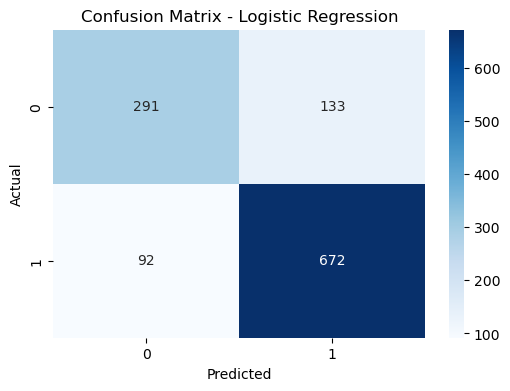

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [16]:
from sklearn.model_selection import cross_val_score

knn_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5)
print("KNN CV Accuracy:", knn_scores.mean())

KNN CV Accuracy: 0.7959511949915459


In [17]:
import joblib

joblib.dump(knn_model, "/Users/skush/CodeX/Stress-Level-Classifier/Models/knn_81.pkl")

['/Users/skush/CodeX/Stress-Level-Classifier/Models/knn_81.pkl']